## Three-Model Zero-Shot Object Detection Comparison
## YOLOE vs OWLv2 vs GroundingDINO

This notebook presents a controlled image-level zero-shot object detection benchmark comparing YOLOE, OWLv2, and GroundingDINO under a common evaluation protocol.

Zero-shot object detection is increasingly important in AI and robotics, where autonomous systems may need to recognize previously unseen objects without task-specific retraining. This is particularly useful for robots operating in dynamic environments where predefined object categories are restrictive.

All three models use the same 12 COCO validation images, four target concepts, confidence threshold, COCO ground truth, and IoU ≥ 0.50 matching rule. The comparison evaluates detection quality and computational efficiency through precision, recall, F1-score, localization, latency, throughput, and model size.

The goal is to identify the accuracy–efficiency trade-offs relevant to real-world robotic perception. ByteTrack is excluded because it introduces temporal tracking, while this benchmark evaluates all three models as image-level detectors.

## Experimental Design

The controlled evaluation holds the following variables constant:

| Component | Controlled setting |
|---|---|
| Evaluation images | Same 12 COCO validation images |
| Target concepts | `cat`, `remote control`, `dog`, `train` |
| Ground truth | COCO `instances_val2017.json` |
| Confidence threshold | 0.35 |
| GroundingDINO text threshold | 0.25 |
| Matching threshold | IoU ≥ 0.50 |
| Evaluation unit | Individual image |
| Runtime measurement | Per-image inference latency |
| Hardware | Same runtime/session |
| Random seed | 42 |

The primary comparison covers **detection accuracy, class-level performance, latency, throughput, parameter count, detection density, and confidence**.


# Environment and Reproducibility

The environment is installed first so that all three model interfaces are available in the same runtime. The notebook records the device, seed, checkpoints, thresholds, and output directory for reproducibility.


In [ ]:
!pip install -q ultralytics transformers pycocotools


In [ ]:
import os
import gc
import time
import json
import random
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
from pycocotools.coco import COCO
from transformers import (
    Owlv2Processor,
    Owlv2ForObjectDetection,
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_DIR = Path("/content/yoloe_owlv2_groundingdino_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR = OUTPUT_DIR / "images"
IMAGE_DIR.mkdir(exist_ok=True)
IMAGE_IDS = [
    1353, 1675, 3934, 4795,
    6040, 7386, 7795, 10363,
    10707, 14380, 17029, 22192
]
TARGET_LABELS = [
    "cat",
    "remote control",
    "dog",
    "train"
]

TEXT_PROMPT = "cat . remote control . dog . train ."
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
GT_LABEL_MAP = {
    "cat": "cat",
    "remote control": "remote",
    "dog": "dog",
    "train": "train"
}
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Seed:", SEED)


## 1. Shared Images and COCO Ground Truth

The image retrieval and ground-truth construction are performed once. Every model receives exactly the same RGB images, and every prediction is evaluated against the same COCO annotations.


In [ ]:
image_paths = []

for image_id in IMAGE_IDS:
    path = IMAGE_DIR / f"{image_id:012d}.jpg"
    if not path.exists():
        url = f"http://images.cocodataset.org/val2017/{image_id:012d}.jpg"
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        path.write_bytes(response.content)
    image_paths.append(path)

images = [
    Image.open(path).convert("RGB")
    for path in image_paths
]
for image_id, image in zip(IMAGE_IDS, images):
    print(image_id, image.size)


In [ ]:
fig, axes = plt.subplots(
    3,4,
    figsize=(16, 11)
)
for ax, image_id, image in zip(
    axes.ravel(),
    IMAGE_IDS,
    images
):
    ax.imshow(image)
    ax.set_title(str(image_id))
    ax.axis("off")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shared_images.png",
    dpi=200
)
plt.show()


In [ ]:
COCO_ANN_PATH = "/content/annotations/instances_val2017.json"

if not os.path.exists(COCO_ANN_PATH):
    os.system(
        "wget -q "
        "http://images.cocodataset.org/annotations/annotations_trainval2017.zip "
        "-O /content/annotations_trainval2017.zip"
    )
    os.system(
        "unzip -q "
        "/content/annotations_trainval2017.zip "
        "-d /content/"
    )
coco = COCO(COCO_ANN_PATH)

gt_records = {}
for image_id in IMAGE_IDS:
    category_ids = coco.getCatIds(
        catNms=["cat", "remote", "dog", "train"]
    )
    annotation_ids = coco.getAnnIds(
        imgIds=[image_id],
        catIds=category_ids,
        iscrowd=None
    )
    annotations = coco.loadAnns(annotation_ids)
    gt_records[image_id] = []
    for annotation in annotations:
        x, y, w, h = annotation["bbox"]
        category = coco.loadCats(
            [annotation["category_id"]]
        )[0]["name"]
        gt_records[image_id].append({
            "label": category,
            "bbox": [
                x,y,
                x + w,
                y + h
            ]
        })
print(
    "Ground-truth objects:",
    sum(map(len, gt_records.values()))
)


## 2. Common Evaluation and Benchmarking Functions

All three models are evaluated through the same label normalization, IoU calculation, one-to-one matching, and aggregate metric definitions.

A prediction is considered a true positive only when it matches an unused ground-truth object of the correct class with IoU ≥ 0.50.


In [ ]:
def norm_label(x):
    s = str(x).lower().strip().replace(".", "")
    for key in TARGET_LABELS:
        if key in s:
            return key
        if key == "remote control" and "remote" in s:
            return key
    return s

In [ ]:
def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    intersection = (
        max(ix2 - ix1, 0)
        * max(iy2 - iy1, 0)
    )

    area_a = (
        max(ax2 - ax1, 0)
        * max(ay2 - ay1, 0)
    )
    area_b = (
        max(bx2 - bx1, 0)
        * max(by2 - by1, 0)
    )

    union = area_a + area_b - intersection
    return (
        intersection / union
        if union > 0
        else 0
    )

In [ ]:
def evaluate(preds):
    tp = 0
    fp = 0
    fn = 0

    matched_ious = []

    for image_id in IMAGE_IDS:
        predictions = sorted(
            [
                p
                for p in preds[image_id]
                if norm_label(p["label"]) in TARGET_LABELS
            ],
            key=lambda z: z["score"],
            reverse=True
        )
        ground_truth = gt_records[image_id]
        used = set()
        for prediction in predictions:
            predicted_label = norm_label(
                prediction["label"]
            )
            best_index = None
            best_iou = 0
            for j, gt in enumerate(ground_truth):
                if j in used:
                    continue
                if GT_LABEL_MAP[predicted_label] != gt["label"]:
                    continue
                value = iou(
                    prediction["bbox"],
                    gt["bbox"]
                )
                if value > best_iou:
                    best_iou = value
                    best_index = j
            if (
                best_index is not None
                and best_iou >= IOU_THRESHOLD
            ):
                used.add(best_index)
                tp += 1
                matched_ious.append(best_iou)
            else:
                fp += 1
        fn += len(ground_truth) - len(used)
    precision = (
        tp / (tp + fp)
        if tp + fp
        else 0
    )
    recall = (
        tp / (tp + fn)
        if tp + fn
        else 0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0
    )
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Mean Matched IoU": (
            np.mean(matched_ious)
            if matched_ious
            else np.nan
        )
    }


In [ ]:
def parameter_count(model):
    return int(
        sum(
            p.numel()
            for p in model.parameters()
        )
    )

def clear():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Part A — Model Inference

Each detector is loaded independently, but the evaluation protocol remains fixed. Only the model-specific checkpoint, processor, and inference call change.


## 3. YOLOE

Checkpoint: `yoloe-26l-seg.pt`

YOLOE receives the same target vocabulary used by the other detectors. Its predictions are converted into the common `{label, score, bbox}` representation before evaluation.


In [ ]:
from ultralytics import YOLOE
YOLO_CHECKPOINT = "yoloe-26l-seg.pt"
yolo_model = YOLOE(
    YOLO_CHECKPOINT
)
yolo_model.set_classes(
    TARGET_LABELS
)
print(
    "YOLOE checkpoint:",
    YOLO_CHECKPOINT
)
print(
    "YOLOE parameters:",
    parameter_count(yolo_model)
)


In [ ]:
def yolo_predict(image):
    result = yolo_model.predict(
        np.array(image),
        conf=BOX_THRESHOLD,
        verbose=False,
        device=DEVICE
    )[0]
    predictions = []
    if result.boxes is not None:
        for box, score, cls in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
            result.boxes.cls.cpu().numpy().astype(int)
        ):
            predictions.append({
                "label": TARGET_LABELS[cls],
                "score": float(score),
                "bbox": box.tolist()
            })
    return predictions


In [ ]:
yolo_preds = {}
yolo_times = []
for image_id, image in zip(
    IMAGE_IDS,
    images
):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    yolo_preds[image_id] = yolo_predict(image)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    yolo_times.append(elapsed)
    print(
        image_id,
        "detections:",
        len(yolo_preds[image_id]),
        "time:",
        elapsed
    )


## 4. OWLv2

Checkpoint: `google/owlv2-base-patch16-ensemble`

OWLv2 is evaluated through the Hugging Face Transformers interface. The same target concepts, image set, confidence threshold, and post-processing convention are used.


In [ ]:
OWL_CHECKPOINT = (
    "google/owlv2-base-patch16-ensemble"
)
owl_processor = Owlv2Processor.from_pretrained(
    OWL_CHECKPOINT
)
owl_model = Owlv2ForObjectDetection.from_pretrained(
    OWL_CHECKPOINT
).to(DEVICE).eval()
print(
    "OWLv2 checkpoint:",
    OWL_CHECKPOINT
)
print(
    "OWLv2 parameters:",
    parameter_count(owl_model)
)


In [ ]:
def owl_predict(image):
    inputs = owl_processor(
        text=[TARGET_LABELS],
        images=image,
        return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        outputs = owl_model(**inputs)
    results = owl_processor.post_process_grounded_object_detection(
        outputs,
        target_sizes=torch.tensor(
            [image.size[::-1]],
            device=DEVICE
        ),
        threshold=BOX_THRESHOLD
    )[0]
    predictions = []
    for box, score, label in zip(
        results["boxes"],
        results["scores"],
        results["labels"]
    ):
        predictions.append({
            "label": TARGET_LABELS[int(label)],
            "score": float(score),
            "bbox": box.detach().cpu().tolist()
        })
    return predictions


In [ ]:
owl_preds = {}
owl_times = []
for image_id, image in zip(
    IMAGE_IDS,
    images
):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    owl_preds[image_id] = owl_predict(image)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    owl_times.append(elapsed)
    print(
        image_id,
        "detections:",
        len(owl_preds[image_id]),
        "time:",
        elapsed
    )


## 5. GroundingDINO — Hugging Face Transformers

Checkpoint: `IDEA-Research/grounding-dino-tiny`

GroundingDINO is explicitly implemented through the **Hugging Face Transformers interface**, using `AutoProcessor` and `AutoModelForZeroShotObjectDetection`.

The semantic prompt is kept identical across all GroundingDINO images, and the processor's grounded post-processing converts the model output into image-space bounding boxes.


In [ ]:
HF_MODEL_ID = (
    "IDEA-Research/grounding-dino-tiny"
)
print(
    f"Loading Hugging Face GroundingDINO: "
    f"{HF_MODEL_ID}..."
)
dino_processor = AutoProcessor.from_pretrained(
    HF_MODEL_ID
)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    HF_MODEL_ID
).to(DEVICE).eval()
print(
    "Hugging Face GroundingDINO loaded."
)
print(
    "Checkpoint:",
    HF_MODEL_ID
)
print(
    "Parameters:",
    parameter_count(dino_model)
)


In [ ]:
def dino_predict(image):
    inputs = dino_processor(
        images=image,
        text=[TEXT_PROMPT],
        return_tensors="pt"
    ).to(DEVICE)

    with torch.inference_mode():
        outputs = dino_model(**inputs)

    results = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=BOX_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
        target_sizes=[image.size[::-1]]
    )[0]

    predictions = []
    for box, score, label in zip(
        results["boxes"],
        results["scores"],
        results["labels"]
    ):
        predictions.append({
            "label": norm_label(label),
            "score": float(
                score.detach().cpu()
            ),
            "bbox": box.detach().cpu().tolist()
        })
    return predictions


In [ ]:
dino_preds = {}
dino_times = []
for image_id, image in zip(
    IMAGE_IDS,
    images
):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    dino_preds[image_id] = dino_predict(image)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    dino_times.append(elapsed)
    print(
        image_id,
        "detections:",
        len(dino_preds[image_id]),
        "time:",
        elapsed
    )


# Part B — Same-Image Qualitative Comparison

Every model sees exactly the same RGB image. The visualization uses the same layout and bounding-box representation for all three models:

**RGB image → YOLOE → OWLv2 → GroundingDINO**


In [ ]:
def draw(ax, image, predictions, title):
    ax.imshow(image)
    for detection in predictions:
        x1, y1, x2, y2 = detection["bbox"]
        ax.add_patch(
            plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )
        )
        ax.text(
            x1,
            max(0, y1 - 4),
            f'{detection["label"]} '
            f'{detection["score"]:.2f}',
            fontsize=7,
            bbox=dict(
                facecolor="white",
                alpha=0.75
            )
        )
    ax.set_title(title)
    ax.axis("off")


In [ ]:
for image_id, image in zip(
    IMAGE_IDS,
    images
):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )
    draw(
        axes[0],
        image,
        yolo_preds[image_id],
        f"YOLOE | {image_id}"
    )
    draw(
        axes[1],
        image,
        owl_preds[image_id],
        f"OWLv2 | {image_id}"
    )
    draw(
        axes[2],
        image,
        dino_preds[image_id],
        f"GroundingDINO | {image_id}"
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"visual_{image_id}.png",
        dpi=180
    )
    plt.show()


# Part C — Quantitative Detection Performance

The primary detection metrics are computed from the same TP/FP/FN matching procedure for all three models.

The comparison includes **precision, recall, F1, and mean matched IoU**. These metrics are calculated independently of runtime so that computational efficiency does not contaminate detection quality.


In [ ]:
accuracy = pd.DataFrame([
    {
        "Model": "YOLOE",
        **evaluate(yolo_preds)
    },
    {
        "Model": "OWLv2",
        **evaluate(owl_preds)
    },
    {
        "Model": "GroundingDINO",
        **evaluate(dino_preds)
    }
])
display(
    accuracy.round(4)
)
accuracy.to_csv(
    OUTPUT_DIR / "accuracy.csv",
    index=False
)


In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)
for ax, metric in zip(
    axes,
    ["Precision", "Recall", "F1"]
):
    ax.bar(
        accuracy["Model"],
        accuracy[metric]
    )
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(
        axis="x",
        rotation=20
    )
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "accuracy_metrics.png",
    dpi=200
)
plt.show()


## 6. Per-Class Metrics

Aggregate metrics can conceal class-specific failure modes. Therefore, each target concept is evaluated separately using the same matching procedure.

This identifies whether a model's aggregate performance is driven by strong performance on one class or is consistent across the four queried concepts.


In [ ]:
def per_class(preds):
    rows = []
    for target in TARGET_LABELS:
        tp = 0
        fp = 0
        fn = 0
        matched_ious = []
        for image_id in IMAGE_IDS:
            predictions = sorted(
                [
                    p
                    for p in preds[image_id]
                    if norm_label(p["label"]) == target
                ],
                key=lambda z: z["score"],
                reverse=True
            )
            ground_truth = [
                g
                for g in gt_records[image_id]
                if g["label"] == GT_LABEL_MAP[target]
            ]
            used = set()
            for prediction in predictions:
                best_index = None
                best_iou = 0
                for j, gt in enumerate(ground_truth):
                    if j in used:
                        continue
                    value = iou(
                        prediction["bbox"],
                        gt["bbox"]
                    )
                    if value > best_iou:
                        best_iou = value
                        best_index = j
                if (
                    best_index is not None
                    and best_iou >= IOU_THRESHOLD
                ):
                    used.add(best_index)
                    tp += 1
                    matched_ious.append(best_iou)
                else:
                    fp += 1
            fn += len(ground_truth) - len(used)
        precision = (
            tp / (tp + fp)
            if tp + fp
            else 0
        )
        recall = (
            tp / (tp + fn)
            if tp + fn
            else 0
        )
        f1 = (
            2 * precision * recall
            / (precision + recall)
            if precision + recall
            else 0
        )
        rows.append({
            "Class": target,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Mean IoU": (
                np.mean(matched_ious)
                if matched_ious
                else np.nan
            )
        })
    return pd.DataFrame(rows)


In [ ]:
per_class_results = []
for model_name, predictions in [
    ("YOLOE", yolo_preds),
    ("OWLv2", owl_preds),
    ("GroundingDINO", dino_preds)
]:
    result = per_class(predictions)
    result.insert(
        0,
        "Model",
        model_name
    )
    per_class_results.append(result)
per_class_df = pd.concat(
    per_class_results,
    ignore_index=True
)
display(
    per_class_df.round(4)
)
per_class_df.to_csv(
    OUTPUT_DIR / "per_class.csv",
    index=False
)


# Part D — Computational Performance

Runtime excludes model loading and image download. CUDA synchronization is used before and after each inference call when CUDA is available.

The comparison reports mean, median, standard deviation, minimum and maximum latency, throughput, parameter count, detection density, and mean confidence.


In [ ]:
def runtime_row(
    name,
    times,
    model,
    predictions
):
    timing = np.array(times)
    scores = [
        detection["score"]
        for image_id in IMAGE_IDS
        for detection in predictions[image_id]
    ]
    return {
        "Model": name,
        "Mean Latency (ms)":
            timing.mean() * 1000,
        "Median Latency (ms)":
            np.median(timing) * 1000,
        "Std Latency (ms)":
            timing.std() * 1000,
        "Min Latency (ms)":
            timing.min() * 1000,
        "Max Latency (ms)":
            timing.max() * 1000,
        "Images/s":
            1 / timing.mean(),
        "Parameters (M)":
            parameter_count(model) / 1e6,
        "Mean Detections/Image":
            sum(
                map(len, predictions.values())
            ) / len(IMAGE_IDS),
        "Mean Confidence":
            np.mean(scores)
            if scores
            else 0
    }
runtime_df = pd.DataFrame([
    runtime_row(
        "YOLOE",
        yolo_times,
        yolo_model,
        yolo_preds
    ),
    runtime_row(
        "OWLv2",
        owl_times,
        owl_model,
        owl_preds
    ),
    runtime_row(
        "GroundingDINO",
        dino_times,
        dino_model,
        dino_preds
    )
])
display(
    runtime_df.round(3)
)
runtime_df.to_csv(
    OUTPUT_DIR / "runtime.csv",
    index=False
)


## 7. Mean Inference Latency


In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)
ax.bar(
    runtime_df["Model"],
    runtime_df["Mean Latency (ms)"]
)
ax.set_ylabel("ms/image")
ax.set_title("Mean Inference Latency")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "latency.png",
    dpi=200
)
plt.show()


## 8. Inference Throughput


In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)
ax.bar(
    runtime_df["Model"],
    runtime_df["Images/s"]
)
ax.set_ylabel("images/s")
ax.set_title("Inference Throughput")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "throughput.png",
    dpi=200
)
plt.show()


## 9. Accuracy–Efficiency Interpretation

Accuracy and computational cost should be interpreted together for deployment-oriented model selection.

The final analysis therefore keeps the detection metrics and runtime statistics separate before joining them into the final comparison table.


# Part E — Final Controlled Comparison

The final table combines the primary detection metrics with computational measurements. No arbitrary weighted score is introduced; accuracy and efficiency remain separately observable.


In [ ]:
final_comparison = accuracy.merge(
    runtime_df,
    on="Model"
)
display(
    final_comparison.round(4)
)
final_comparison.to_csv(
    OUTPUT_DIR / "final_comparison.csv",
    index=False
)


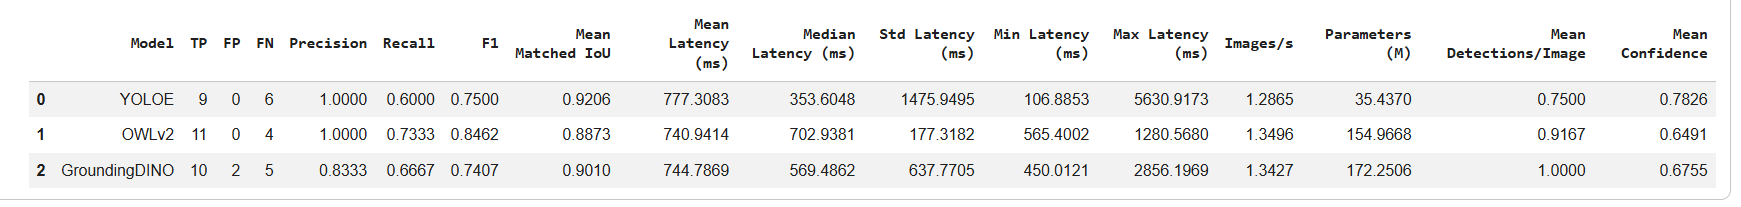

## 10. Checkpoint and Experimental Configuration

The exact model checkpoints, prompt, thresholds, image IDs, device, and evaluation interface are recorded so the experiment can be reconstructed without ambiguity.


In [ ]:
experiment_record = {
    "experiment":
        "YOLOE vs OWLv2 vs GroundingDINO",
    "seed":
        SEED,
    "device":
        DEVICE,
    "images":
        IMAGE_IDS,
    "targets":
        TARGET_LABELS,
    "prompt":
        TEXT_PROMPT,
    "thresholds": {
        "box":
            BOX_THRESHOLD,
        "text":
            TEXT_THRESHOLD,
        "iou":
            IOU_THRESHOLD
    },
    "checkpoints": {
        "YOLOE":
            YOLO_CHECKPOINT,
        "OWLv2":
            OWL_CHECKPOINT,
        "GroundingDINO":
            HF_MODEL_ID
    },
    "groundingdino_interface":
        "Hugging Face Transformers "
        "(AutoProcessor + "
        "AutoModelForZeroShotObjectDetection)",
    "results":
        final_comparison.to_dict(
            orient="records"
        )
}
with open(
    OUTPUT_DIR / "experiment_record.json",
    "w"
) as file:
    json.dump(
        experiment_record,
        file,
        indent=2
    )
print(
    "Saved experimental record to:",
    OUTPUT_DIR
)


# Interpretation

YOLOE achieved the highest precision (1.00) and the best localization with a mean IoU of 0.9206, while OWLv2 achieved the highest recall (0.7333) and F1-score (0.8462). GroundingDINO showed balanced performance but had more false positives, resulting in the lowest F1-score of 0.7407.

In terms of efficiency, OWLv2 had the lowest mean latency (740.94 ms) and the highest throughput at 1.35 images/s, while YOLOE had the smallest model size at 35.44M parameters. GroundingDINO had a similar latency to OWLv2 but required the largest model size (172.25M parameters). Overall, OWLv2 provides the best balance of detection accuracy and speed, whereas YOLOE is more attractive for precision and resource-constrained deployment.

# Limitations and Reproducibility Notes

1. The supplied first notebook contains **OWLv2**, not OWLv3; this notebook therefore evaluates OWLv2.
2. The evaluation subset contains 12 COCO validation images and four queried concepts. It is a controlled comparison, not a full COCO benchmark.
3. The matching protocol uses a single IoU threshold of 0.50. Formal COCO evaluation would report AP across multiple IoU thresholds.
4. Runtime is hardware- and environment-dependent and should be interpreted as a measurement of this execution environment.
5. The same confidence threshold is applied for the common comparison, while GroundingDINO additionally uses its text threshold.
6. ByteTrack is excluded because temporal tracking is not shared across the three image-level detection pipelines.
7. The comparison uses different pretrained model architectures and checkpoints; therefore, the result is a model-level comparison, not a controlled comparison of identical parameterizations.


# Conclusion

In this controlled evaluation, OWLv2 achieved the best overall detection performance, with the highest F1-score (0.8462) and recall (0.7333), while maintaining the lowest mean latency (740.94 ms/image). YOLOE achieved perfect precision (1.00), the highest localization IoU (0.9206), and the smallest model size (35.44M parameters), making it attractive for precision- and resource-constrained deployment. GroundingDINO showed strong localization and recall but produced false positives, resulting in a lower F1-score (0.7407). Overall, OWLv2 performed best for detection quality, while YOLOE offered the strongest precision and compactness.